# Ensemble Models: Train-Test Gap Analysis

**Author:** Sabri Hamdaoui  
**Phase 4 Technical Modification**

This notebook extends the original ensemble-model example by adding weighted
F1 scores, train-test performance gaps, a sorted comparison table, and a chart
that compares training and test accuracy.


## M5. Ensemble Models

This notebook fits a single model and 
two ensembles and 
reports their test scores side by side. 

The analyst decides whether an ensemble's extra complexity is earned, that is, 
whether it creates a real gain, 
rather than just noise.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models 
so their errors partly cancel. 

This module reuses the Module 3 classification setup and asks one question: 

- Does combining models beat the single model in this problem?

## Overview

This project uses the penguins dataset.
We choose to predict the target `species`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- an ensemble model because we are choosing to combine approaches to see if we can improve on the classification model in Module 3.

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-30 04:14:53 | INFO | M05 | === RUN START ===
2026-07-30 04:14:53 | INFO | M05 | project=M05
2026-07-30 04:14:53 | INFO | M05 | repo_dir=ml-05-ensembles
2026-07-30 04:14:53 | INFO | M05 | python=3.14.4
2026-07-30 04:14:53 | INFO | M05 | os=Windows 11
2026-07-30 04:14:53 | INFO | M05 | shell=powershell
2026-07-30 04:14:53 | INFO | M05 | cwd=notebooks
2026-07-30 04:14:53 | INFO | M05 | github_actions=False
2026-07-30 04:14:53 | INFO | M05 | Confirming installation:
2026-07-30 04:14:53 | INFO | M05 |   python:       3.14.4
2026-07-30 04:14:53 | INFO | M05 |   pandas:       3.0.5
2026-07-30 04:14:53 | INFO | M05 |   numpy:        2.5.1
2026-07-30 04:14:53 | INFO | M05 |   scikit-learn: 1.9.0
2026-07-30 04:14:53 | INFO | M05 |   seaborn:      0.13.2
2026-07-30 04:14:53 | INFO | M05 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [2]:
# === Section 2. Load and Prepare the Data ===


# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "species"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-07-30 04:14:53 | INFO | M05 | Loading dataset: penguins
2026-07-30 04:14:53 | INFO | M05 | Loaded: 344 rows (instances), 7 columns
2026-07-30 04:14:53 | INFO | M05 | Original rows: 344
2026-07-30 04:14:53 | INFO | M05 | Model rows:    342
2026-07-30 04:14:53 | INFO | M05 | Classes in target 'species': ['Adelie', 'Chinstrap', 'Gentoo']
2026-07-30 04:14:53 | DEBUG | M05 | Class counts:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [3]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-30 04:14:53 | INFO | M05 | Train instances: 273
2026-07-30 04:14:53 | INFO | M05 | Test instances: 69


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [4]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingClassifier(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-07-30 04:14:53 | INFO | M05 | Fitting single tree + two ensembles
2026-07-30 04:14:53 | DEBUG | M05 |   fitted: single_tree
2026-07-30 04:14:54 | DEBUG | M05 |   fitted: random_forest
2026-07-30 04:14:54 | DEBUG | M05 |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-07-30 04:16:47 | INFO | M05 | single_tree        train accuracy=0.967, test accuracy=0.986, accuracy gap=-0.018, test F1=0.985


2026-07-30 04:16:47 | INFO | M05 | random_forest      train accuracy=1.000, test accuracy=1.000, accuracy gap=0.000, test F1=1.000
2026-07-30 04:16:47 | INFO | M05 | gradient_boosting  train accuracy=1.000, test accuracy=0.986, accuracy gap=0.014, test F1=0.986



Model Performance Comparison:
            Model  Train Accuracy  Test Accuracy  Accuracy Gap  Train F1  Test F1  F1 Gap
    random_forest           1.000          1.000         0.000     1.000    1.000   0.000
gradient_boosting           1.000          0.986         0.014     1.000    0.986   0.014
      single_tree           0.967          0.986        -0.018     0.967    0.985  -0.018


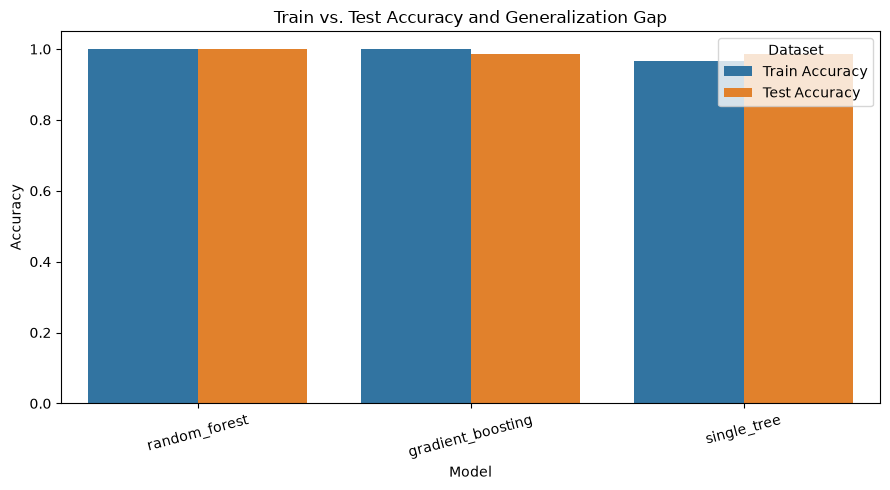

2026-07-30 04:16:48 | INFO | M05 | Best model: random_forest, test accuracy=1.000, accuracy gap=0.000


In [8]:
# === Section 5. Compare Train and Test Performance ===

"""Evaluate all models using accuracy and weighted F1 score.

This modification adds:
- train and test accuracy
- train and test F1 score
- accuracy and F1 generalization gaps
- a sorted comparison table
- a chart comparing train and test accuracy

A smaller train-test gap generally indicates better generalization.
"""

models = {
    "single_tree": modelA,
    "random_forest": modelB,
    "gradient_boosting": modelC,
}

results: list[dict[str, str | float]] = []

for model_name, model in models.items():
    # Generate predictions for both training and held-out test data.
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate accuracy.
    train_accuracy = float(accuracy_score(y_train, y_train_pred))
    test_accuracy = float(accuracy_score(y_test, y_test_pred))

    # Calculate weighted F1 because this is a multiclass problem.
    train_f1 = float(f1_score(y_train, y_train_pred, average="weighted"))
    test_f1 = float(f1_score(y_test, y_test_pred, average="weighted"))

    # Calculate generalization gaps.
    accuracy_gap = train_accuracy - test_accuracy
    f1_gap = train_f1 - test_f1

    results.append(
        {
            "Model": model_name,
            "Train Accuracy": train_accuracy,
            "Test Accuracy": test_accuracy,
            "Accuracy Gap": accuracy_gap,
            "Train F1": train_f1,
            "Test F1": test_f1,
            "F1 Gap": f1_gap,
        }
    )

    LOG.info(
        f"{model_name:18s} "
        f"train accuracy={train_accuracy:.3f}, "
        f"test accuracy={test_accuracy:.3f}, "
        f"accuracy gap={accuracy_gap:.3f}, "
        f"test F1={test_f1:.3f}"
    )

# Create and sort the comparison table.
results_df = (
    pd.DataFrame(results)
    .sort_values(
        by=["Test Accuracy", "Test F1", "Accuracy Gap"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

print("\nModel Performance Comparison:")
print(results_df.round(3).to_string(index=False))

# Reshape the accuracy columns for charting.
accuracy_plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Train Accuracy", "Test Accuracy"],
    var_name="Dataset",
    value_name="Accuracy",
)

# Plot train and test accuracy together.
plt.figure(figsize=(9, 5))

sns.barplot(
    data=accuracy_plot_df,
    x="Model",
    y="Accuracy",
    hue="Dataset",
)

plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Train vs. Test Accuracy and Generalization Gap")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    "../docs/images/phase4_train_test_gap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# Identify the best model after sorting.
best_model = str(results_df.iloc[0]["Model"])
best_test_accuracy = float(results_df.iloc[0]["Test Accuracy"])
best_accuracy_gap = float(results_df.iloc[0]["Accuracy Gap"])

LOG.info(
    f"Best model: {best_model}, "
    f"test accuracy={best_test_accuracy:.3f}, "
    f"accuracy gap={best_accuracy_gap:.3f}"
)

### Interpretation



### Phase 4 Technical Modification and Interpretation

I modified the example notebook to compare both training and test performance
instead of reporting only test accuracy. I added weighted F1 scores and calculated
accuracy and F1 generalization gaps for each model. I also created a sorted results
table and a chart comparing train and test accuracy.

The Random Forest performed best, with 1.000 train accuracy, 1.000 test accuracy,
and a generalization gap of 0.000. Gradient Boosting also fit the training data
perfectly but achieved 0.986 test accuracy, producing a small gap of 0.014.

The single decision tree achieved 0.967 train accuracy and 0.986 test accuracy.
Its negative gap of -0.018 means it performed slightly better on this particular
test split than on the training set. This can occur because the test set contains
only 69 records.

The modification provides more information than test accuracy alone because it
helps identify possible overfitting and shows how consistently each model performs.
For this split, Random Forest provided the strongest performance and the smallest
generalization gap.

## Section 6. Which Features Did the Forest Rely On?

2026-07-30 04:14:55 | INFO | M05 | Random forest feature importances (high to low):
2026-07-30 04:14:55 | INFO | M05 |   bill_length_mm       0.404
2026-07-30 04:14:55 | INFO | M05 |   flipper_length_mm    0.301
2026-07-30 04:14:55 | INFO | M05 |   bill_depth_mm        0.219
2026-07-30 04:14:55 | INFO | M05 |   body_mass_g          0.076


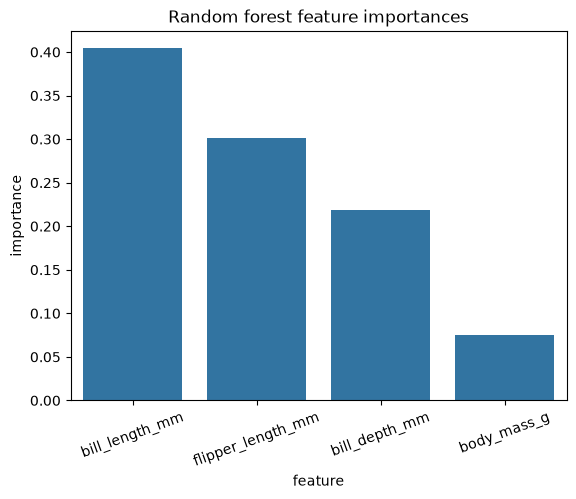

In [6]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [7]:
# === Python Summary ===

"""Record what was compared and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info("Compared: single tree vs. random forest vs. gradient boosting")
LOG.info("========================")

2026-07-30 04:14:55 | INFO | M05 | ========================
2026-07-30 04:14:55 | INFO | M05 | SUMMARY
2026-07-30 04:14:55 | INFO | M05 | ========================
2026-07-30 04:14:55 | INFO | M05 | Dataset: penguins   Target: species (classification)
2026-07-30 04:14:55 | INFO | M05 | Compared: single tree vs. random forest vs. gradient boosting
2026-07-30 04:14:55 | INFO | M05 | ========================



### Custom Narrative

Summarize your work in this Markdown cell in your notebook.

YOUR JUDGMENT (include a summary in docs/index.md also):

- Did either ensemble beat the single tree on the test set?
- Was the gain worth the extra training cost and lost simplicity?
- Do the feature importances match what you expected? Any surprises?

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.


## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Re-run on a harder target (`"sex"`) and see whether the ensemble's
   advantage over the single tree grows when the problem is harder.
2. **Extend** - Tune `n_estimators` and `max_depth` for the random forest and report
   whether more trees kept helping or flattened out (diminishing returns).
3. **Explore** - Find a case where the ensemble does **not** beat the single tree,
   and argue in `docs/index.md` why the simpler model is the better choice there.

## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
